# PPE Detection — YOLO11 Fine-Tuning


## 1. Setup

In [1]:
!pip install ultralytics mlflow roboflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/

In [23]:
! pip install pyngrok

In [4]:
import os
import json
import shutil
from pathlib import Path

import mlflow
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO, settings as yolo_settings

import cv2
import yaml
import random


# Create project folders directly in Colab
ROOT = Path("/content/ppe_project")
dirs = [
    "models",
    "outputs/training",
    "outputs/screenshots",
    "data/processed",
    "mlruns",
]
for d in dirs:
    (ROOT / d).mkdir(parents=True, exist_ok=True)

os.chdir(ROOT)
print(f"Working dir: {ROOT}")
print("Folders created ")

Working dir: /content/ppe_project
Folders created 


## 2. Hyperparameter Config


In [5]:
CONFIG = {
    "base_model":     "yolo11s.pt",
    "imgsz":          640,
    "epochs":         120,
    "batch":          16,
    "device":         "0",

    "lr0":            0.01,
    "lrf":            0.01,
    "momentum":       0.937,
    "weight_decay":   0.0005,
    "warmup_epochs":  3,
    "patience":       35,
    "cls":            1.0,

    "hsv_h":          0.015,
    "hsv_s":          0.7,
    "hsv_v":          0.4,
    "degrees":        17.0,
    "translate":      0.1,
    "scale":          0.7,
    "flipud":         0.1,
    "fliplr":         0.5,
    "mosaic":         1.0,
    "mixup":          0.15,
    "copy_paste":     0.3,

    "conf":           0.35,
    "iou":            0.45,

    "dataset_yaml":   "data/processed/ppe_dataset/data.yaml",
    "dataset_source": "roboflow-universe-projects/construction-site-safety/28",
}

## 3. Dataset — Construction Site Safety (Roboflow)


In [ ]:
from roboflow import Roboflow

API_KEY = "YOUR_API_KEY"   # ← paste your key here

rf = Roboflow(api_key=API_KEY)
dataset = rf.workspace("roboflow-universe-projects") \
            .project("construction-site-safety") \
            .version(28) \
            .download("yolov8", location="data/processed/ppe_dataset")

CONFIG["dataset_yaml"] = dataset.location + "/data.yaml"
print(f"Downloaded to: {dataset.location}")
print(f"Classes: Hardhat, Mask, NO-Hardhat, NO-Mask, NO-Safety Vest, Person, Safety Cone, Safety Vest, machinery, vehicle")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to data/processed/ppe_dataset in yolov8:: 100%|██████████| 5614/5614 [00:01<00:00, 5203.29it/s]


Downloaded to: /content/ppe_project/data/processed/ppe_dataset
Classes: Hardhat, Mask, NO-Hardhat, NO-Mask, NO-Safety Vest, Person, Safety Cone, Safety Vest, machinery, vehicle


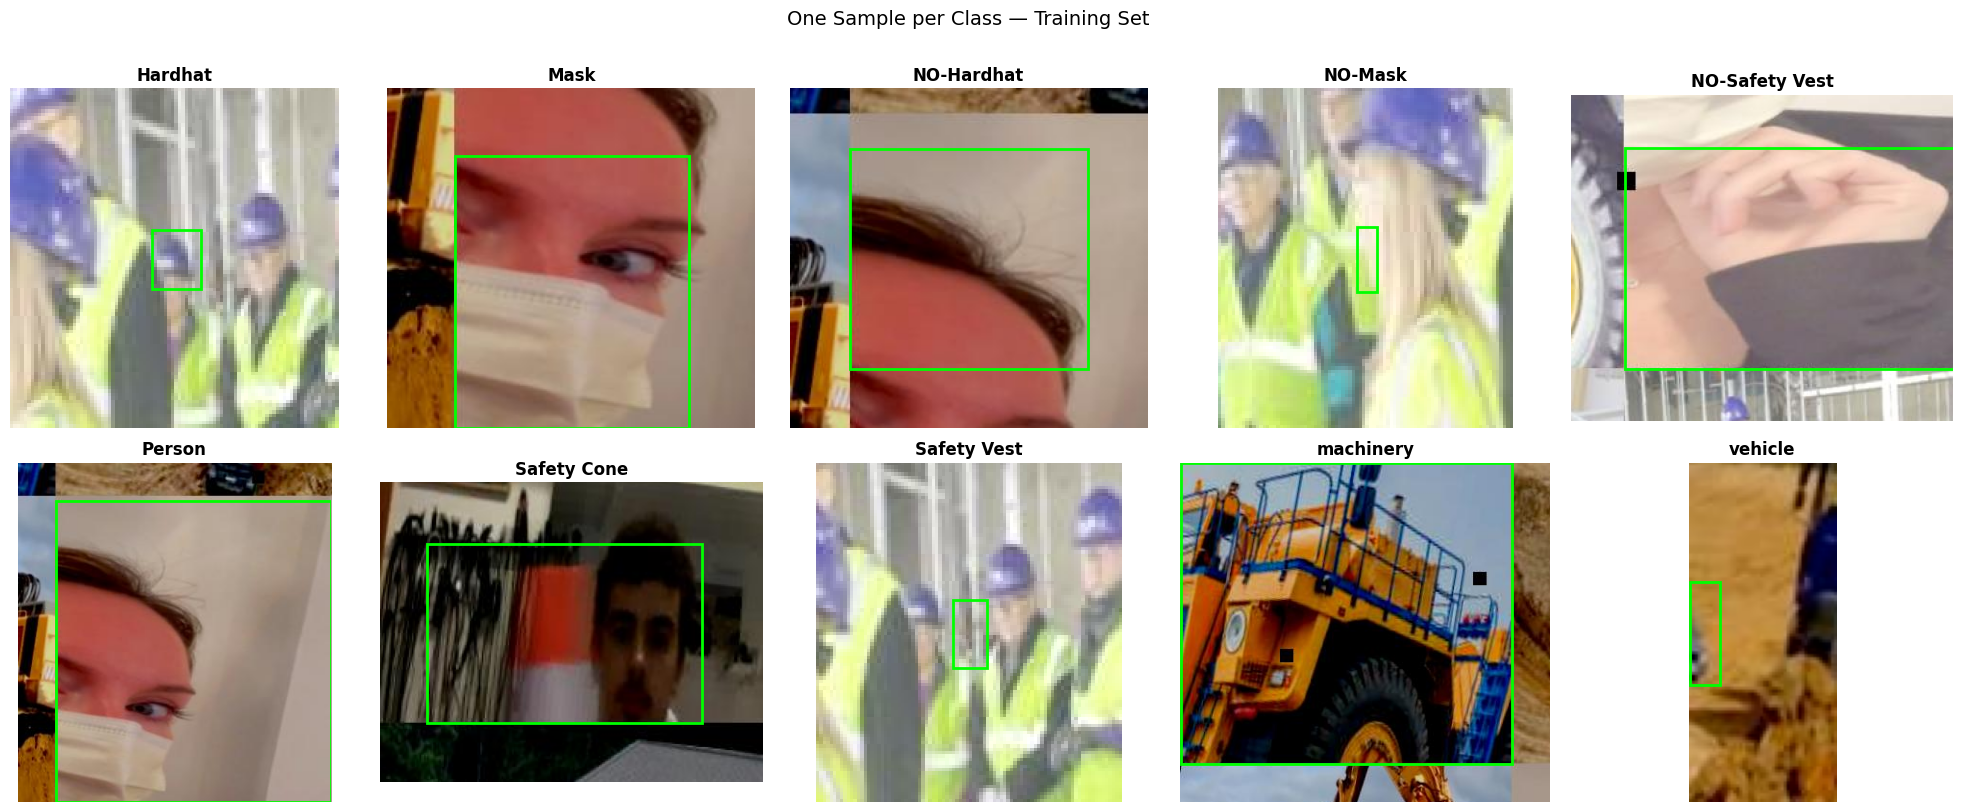

Found samples for 10/10 classes


In [9]:
# Load class names from data.yaml
with open(CONFIG["dataset_yaml"]) as f:
    data_yaml = yaml.safe_load(f)
class_names = data_yaml["names"]

train_img_dir   = Path(CONFIG["dataset_yaml"]).parent / "train" / "images"
train_label_dir = Path(CONFIG["dataset_yaml"]).parent / "train" / "labels"

# Find one sample per class
class_samples = {}

label_files = list(train_label_dir.glob("*.txt"))
random.shuffle(label_files)  # shuffle so we get different samples each run

for label_file in label_files:
    if len(class_samples) == len(class_names):
        break
    lines = label_file.read_text().strip().splitlines()
    random.shuffle(lines)  # shuffle lines too so we don't always pick first bbox
    for line in lines:
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls_id = int(parts[0])
        if cls_id not in class_samples:
            img_path = train_img_dir / (label_file.stem + ".jpg")
            if not img_path.exists():
                img_path = train_img_dir / (label_file.stem + ".png")
            if img_path.exists():
                cx, cy, w, h = map(float, parts[1:5])
                class_samples[cls_id] = (img_path, (cx, cy, w, h))
# Plot
n = len(class_samples)
cols = 5
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flat

for cls_id in sorted(class_samples.keys()):
    img_path, (cx, cy, bw, bh) = class_samples[cls_id]

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]

    # Convert YOLO normalized coords → pixel coords
    x1 = int((cx - bw / 2) * W)
    y1 = int((cy - bh / 2) * H)
    bw_px = int(bw * W)
    bh_px = int(bh * H)

    # Crop with padding
    pad = 40
    x1c = max(0, x1 - pad)
    y1c = max(0, y1 - pad)
    x2c = min(W, x1 + bw_px + pad)
    y2c = min(H, y1 + bh_px + pad)
    crop = img[y1c:y2c, x1c:x2c]

    ax = next(axes)
    ax.imshow(crop)

    # Draw bbox relative to crop
    rect = patches.Rectangle(
        (x1 - x1c, y1 - y1c), bw_px, bh_px,
        linewidth=2, edgecolor="lime", facecolor="none"
    )
    ax.add_patch(rect)
    ax.set_title(class_names[cls_id], fontsize=12, fontweight="bold")
    ax.axis("off")

# Hide unused axes
for ax in axes:
    ax.axis("off")

plt.suptitle("One Sample per Class — Training Set", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("outputs/training/class_samples.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Found samples for {len(class_samples)}/{len(class_names)} classes")

## 4. Training

In [10]:
yolo_settings.update({'mlflow': False})

mlflow.set_tracking_uri("sqlite:///mlruns/mlflow.db")
mlflow.set_experiment("ppe-yolo11-finetuning")

# ── Fix 4: reflect yolo11s in run name ──────────────────────────
RUN_NAME = f"yolo11s_ep{CONFIG['epochs']}_bs{CONFIG['batch']}_lr{CONFIG['lr0']}_v2"

def sanitize_mlflow_key(name: str) -> str:
    return (
        name.strip()
            .replace("/", "_")
            .replace(" ", "")
            .replace("(", "_")
            .replace(")", "")
            .replace("-", "_")
    )

with mlflow.start_run(run_name=RUN_NAME) as run:

    # 1. Log all hyperparameters
    mlflow.log_params(CONFIG)
    print(f"MLflow Run ID: {run.info.run_id}")

    # 2. Load and train
    model = YOLO(CONFIG["base_model"])

    results = model.train(
        data          = CONFIG["dataset_yaml"],
        epochs        = CONFIG["epochs"],
        imgsz         = CONFIG["imgsz"],
        batch         = CONFIG["batch"],
        device        = CONFIG["device"],
        lr0           = CONFIG["lr0"],
        lrf           = CONFIG["lrf"],
        momentum      = CONFIG["momentum"],
        weight_decay  = CONFIG["weight_decay"],
        warmup_epochs = CONFIG["warmup_epochs"],
        patience      = CONFIG["patience"],     # ── Fix 1
        cls           = CONFIG["cls"],           # ── Fix 2
        hsv_h         = CONFIG["hsv_h"],
        hsv_s         = CONFIG["hsv_s"],
        hsv_v         = CONFIG["hsv_v"],
        degrees       = CONFIG["degrees"],
        translate     = CONFIG["translate"],
        scale         = CONFIG["scale"],
        flipud        = CONFIG["flipud"],
        fliplr        = CONFIG["fliplr"],
        mosaic        = CONFIG["mosaic"],
        mixup         = CONFIG["mixup"],
        copy_paste    = CONFIG["copy_paste"],    # ── Fix 3
        project       = "outputs/training",
        name          = RUN_NAME,
        save          = True,
        plots         = True,
    )

    # 3. Log final summary metrics
    m = results.results_dict
    mlflow.log_metrics({
        "final_mAP50":      m.get("metrics/mAP50(B)",    0),
        "final_mAP50_95":   m.get("metrics/mAP50-95(B)", 0),
        "final_precision":  m.get("metrics/precision(B)", 0),
        "final_recall":     m.get("metrics/recall(B)",    0),
        "final_box_loss":   m.get("train/box_loss",       0),
        "final_cls_loss":   m.get("train/cls_loss",       0),
        "final_val_box":    m.get("val/box_loss",         0),
        "final_val_cls":    m.get("val/cls_loss",         0),
    })

    # 4. Per-epoch metrics from results.csv
    save_dir = Path(results.save_dir)
    csv_path = save_dir / "results.csv"

    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df.columns = df.columns.str.strip()

        logged, skipped = 0, 0
        for epoch_idx, row in df.iterrows():
            epoch_metrics = {}
            for col in df.columns:
                try:
                    val = float(row[col])
                    clean_key = sanitize_mlflow_key(col)
                    epoch_metrics[clean_key] = val
                    logged += 1
                except (ValueError, TypeError):
                    skipped += 1
            if epoch_metrics:
                mlflow.log_metrics(epoch_metrics, step=int(epoch_idx))

        print(f"  Per-epoch logging: {logged} values logged, {skipped} skipped")
        mlflow.log_artifact(str(csv_path), artifact_path="training_logs")

    # 5. Log training plots
    for plot in save_dir.glob("*.png"):
        mlflow.log_artifact(str(plot), artifact_path="plots")

    # 6. Save and log best weights
    best_pt = save_dir / "weights" / "best.pt"
    if best_pt.exists():
        Path("models").mkdir(parents=True, exist_ok=True)
        shutil.copy(best_pt, "models/best.pt")
        mlflow.log_artifact(str(best_pt), artifact_path="weights")

    print(f"\n Training complete — Run: {RUN_NAME}")
    print(f"   mAP50:      {m.get('metrics/mAP50(B)', 0):.4f}")
    print(f"   mAP50-95:   {m.get('metrics/mAP50-95(B)', 0):.4f}")
    print(f"   Precision:  {m.get('metrics/precision(B)', 0):.4f}")
    print(f"   Recall:     {m.get('metrics/recall(B)', 0):.4f}")
    print(f"   Saved →     models/best.pt")

LAST_RUN_ID = run.info.run_id
print(f"\nView: mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db")

2026/05/09 14:21:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/09 14:21:25 INFO mlflow.store.db.utils: Updating database tables
2026/05/09 14:21:27 INFO mlflow.tracking.fluent: Experiment with name 'ppe-yolo11-finetuning' does not exist. Creating a new experiment.


MLflow Run ID: bd075bf99a644f31be9a90d4f1fdc237
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ppe_project/data/processed/ppe_dataset/data.yaml, degrees=17.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_ep120_bs16_lr0.01_

## 5. Loss Curves

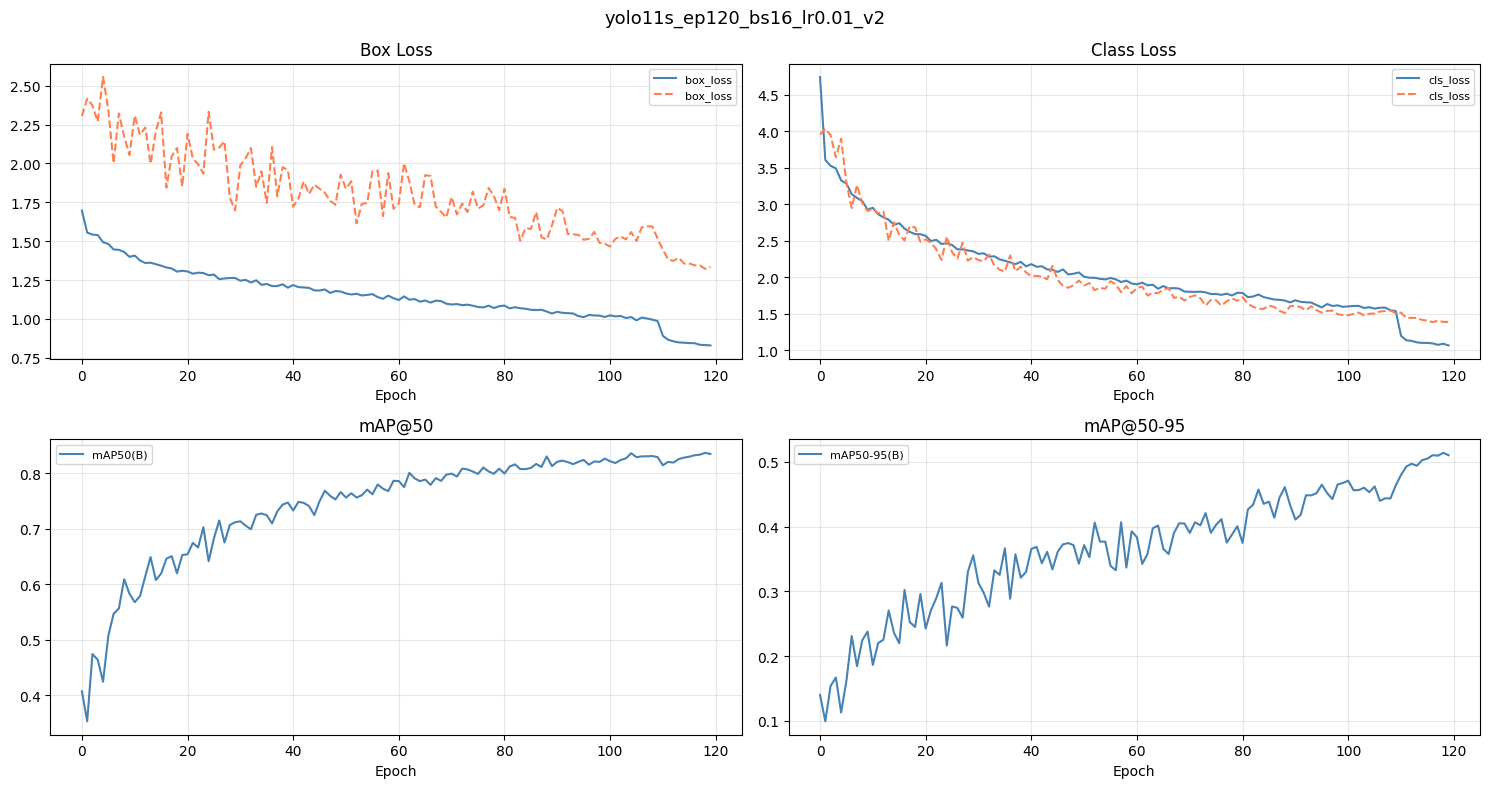

In [12]:
df = pd.read_csv(Path(results.save_dir) / "results.csv")
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle(RUN_NAME, fontsize=13)

plots = [
    ("train/box_loss",       "val/box_loss",        "Box Loss"),
    ("train/cls_loss",       "val/cls_loss",        "Class Loss"),
    ("metrics/mAP50(B)",     None,                  "mAP@50"),
    ("metrics/mAP50-95(B)",  None,                  "mAP@50-95"),
    ("metrics/precision(B)", "metrics/recall(B)",   "Precision / Recall"),
]

for ax, (c1, c2, title) in zip(axes.flat, plots):
    if c1 in df.columns:
        ax.plot(df[c1], label=c1.split("/")[-1], color="steelblue")
    if c2 and c2 in df.columns:
        ax.plot(df[c2], label=c2.split("/")[-1], color="coral", linestyle="--")
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = Path("outputs/training/loss_curves.png")
out_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_path, dpi=120)
plt.show()

mlflow.set_tracking_uri("sqlite:///mlruns/mlflow.db")
with mlflow.start_run(run_id=LAST_RUN_ID):
    mlflow.log_artifact(str(out_path), artifact_path="plots")

## 6. Validation — Per-Class Metrics

In [14]:
model = YOLO("models/best.pt")

val = model.val(
    data    = CONFIG["dataset_yaml"],
    imgsz   = CONFIG["imgsz"],
    conf    = CONFIG["conf"],      # 0.35
    iou     = CONFIG["iou"],       # 0.45
    device  = CONFIG["device"],
    split   = "test",              # run on test set, not val
    plots   = True,)

print(f"Val mAP50:     {val.box.map50:.4f}")
print(f"Val mAP50-95:  {val.box.map:.4f}")
print(f"Val Precision: {val.box.mp:.4f}")
print(f"Val Recall:    {val.box.mr:.4f}")

mlflow.set_tracking_uri("sqlite:///mlruns/mlflow.db")
with mlflow.start_run(run_id=LAST_RUN_ID):
    mlflow.log_metrics({
        "val_final_mAP50":     val.box.map50,
        "val_final_mAP50_95":  val.box.map,
        "val_final_precision": val.box.mp,
        "val_final_recall":    val.box.mr,
    })
print("Validation metrics logged to MLflow")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,416,670 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 26.2±8.1 MB/s, size: 59.8 KB)
val: Scanning /content/ppe_project/data/processed/ppe_dataset/test/labels... 82 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 82/82 681.0it/s 0.1s
val: New cache created: /content/ppe_project/data/processed/ppe_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 1.4it/s 4.4s
                   all         82        760      0.932       0.72      0.705      0.434
               Hardhat         30        110      0.989      0.845      0.844       0.55
                  Mask         16         28          1       0.75      0.745      0.501
            NO-Hardhat         25         41      0.862       0.61      0.522      0.306
               NO-Mask       

## 7. Export to ONNX

In [20]:
model = YOLO("models/best.pt")

onnx_path = model.export(
    format   = "onnx",
    imgsz    = CONFIG["imgsz"],
    dynamic  = True,
    simplify = True,
    opset    = 17,
)


mlflow.set_tracking_uri("sqlite:///mlruns/mlflow.db")
with mlflow.start_run(run_id=LAST_RUN_ID):
    mlflow.log_artifact("models/best.onnx", artifact_path="weights")

print(" ONNX exported → models/best.onnx")
print(" Logged to MLflow")

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO11s summary (fused): 101 layers, 9,416,670 parameters, 0 gradients, 21.3 GFLOPs

PyTorch: starting from 'models/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (18.3 MB)

ONNX: starting export with onnx 1.21.0 opset 17...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 3.4s, saved as 'models/best.onnx' (36.7 MB)

Export complete (4.6s)
Results saved to /content/ppe_project/models/best.onnx
Predict:         yolo predict task=detect model=models/best.onnx imgsz=640 
Validate:        yolo val task=detect model=models/best.onnx imgsz=640 data=/content/ppe_project/data/processed/ppe_dataset/data.yaml  
Visualize:       https://netron.app
 ONNX exported → models/best.onnx
 Logged to MLflow
